# Cubazoid Reproducibility + Visualization Demo

This notebook does three things:
1. Runs representative solver experiments.
2. Shows visual proof (GIF + final 3D snapshot).
3. Runs all test cases and saves GIFs for every solved case.


In [1]:
import json
import time
from pathlib import Path
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from IPython.display import Image, display

from cubazoid.examples import build_test_cases
from cubazoid.solver import CubazoidSolver, ExactCoverCubazoidSolver
from cubazoid.visualization import placements_to_grid, visualize_solution


In [2]:
def verify_solution(solver, placements, piece_count: int) -> Dict[str, bool]:
    if placements is None:
        return {
            'piece_count_ok': False,
            'piece_used_once_ok': False,
            'no_overlap_ok': False,
            'full_fill_ok': False,
        }

    n = solver.n
    all_cells = [cell for p in placements for cell in p.cells]
    unique_cells = set(all_cells)
    used_piece_ids = [p.piece_id for p in placements]
    used_piece_set = set(used_piece_ids)

    return {
        'piece_count_ok': len(placements) == piece_count,
        'piece_used_once_ok': len(used_piece_ids) == len(used_piece_set) == piece_count and used_piece_set == set(range(piece_count)),
        'no_overlap_ok': len(all_cells) == len(unique_cells),
        'full_fill_ok': len(unique_cells) == n ** 3,
    }


def build_solver(pieces: List, backend: str = 'mrv', allow_disconnected: bool = False):
    if backend == 'mrv':
        return CubazoidSolver(pieces, allow_disconnected=allow_disconnected)
    if backend == 'exact':
        return ExactCoverCubazoidSolver(pieces, allow_disconnected=allow_disconnected)
    raise ValueError(f'Unknown backend: {backend}')


## Load Cases

In [3]:
INCLUDE_LARGE = True
cases = build_test_cases(include_large_search_cases=INCLUDE_LARGE)
print('total cases:', len(cases))
print('case names:')
for name in cases:
    print(' -', name)


total cases: 14
case names:
 - easy_3x3x3_all_I3
 - easy_2x2x2_two_4blocks
 - medium_3x3x3_mixed
 - hard_4x4x4_all_I4
 - success_mixed_3_4_5
 - failure_mixed_3_4_5
 - hard_4x4x4_mixed_4blocks
 - hard_4x4x4_mixed_3_5_fail
 - reject_not_perfect_cube
 - reject_disconnected_piece_3x3x3
 - search_5x5x5_mixed_balanced_a
 - search_5x5x5_mixed_balanced_b
 - search_6x6x6_mixed_balanced
 - search_7x7x7_mixed_balanced


## Visual Proof (GIF + Final 3D Snapshot)

Run this cell to generate and display one concrete visual proof.


status: solved | runtime=0.000s
infeasible_reason: None
saved gif: outputs\demo_visual\easy_2x2x2_two_4blocks_mrv.gif


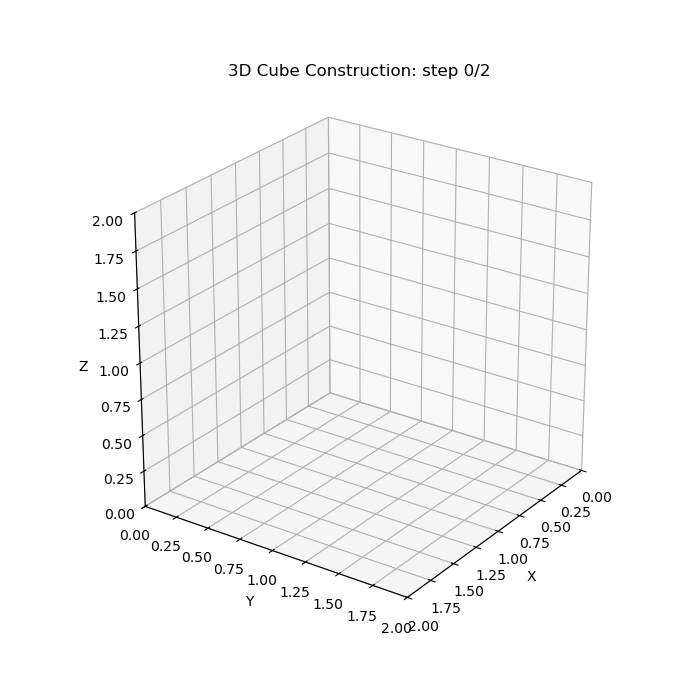

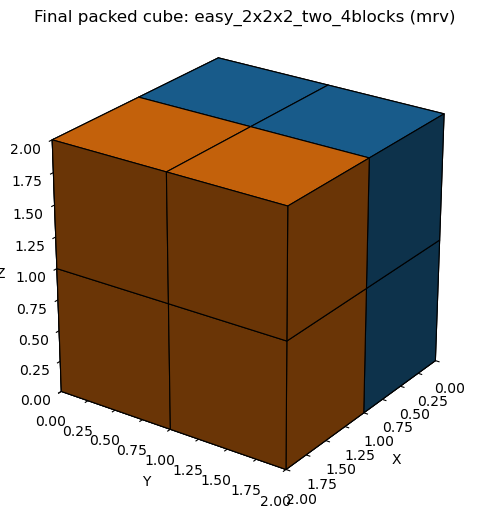

In [4]:
demo_case = 'easy_2x2x2_two_4blocks'  # change if you want
demo_backend = 'mrv'
demo_timeout_sec = 60
demo_interval_ms = 600

demo_pieces = cases[demo_case]
demo_solver = build_solver(demo_pieces, backend=demo_backend)
t0 = time.perf_counter()
demo_placements = demo_solver.solve(max_seconds=demo_timeout_sec)
dt = time.perf_counter() - t0

if demo_solver.timed_out:
    demo_status = 'timeout'
elif demo_placements is not None:
    demo_status = 'solved'
else:
    demo_status = 'unsolved'

print(f'status: {demo_status} | runtime={dt:.3f}s')
print('infeasible_reason:', demo_solver.infeasible_reason)

if demo_placements is None:
    print('No visual output because no solution was produced.')
else:
    out_dir = Path('outputs') / 'demo_visual'
    out_dir.mkdir(parents=True, exist_ok=True)
    gif_path = out_dir / f'{demo_case}_{demo_backend}.gif'
    _ = visualize_solution(
        demo_solver.n,
        demo_placements,
        interval=demo_interval_ms,
        save_path=str(gif_path),
        show=False,
    )
    print('saved gif:', gif_path)
    display(Image(filename=str(gif_path)))

    grid = placements_to_grid(demo_solver.n, demo_placements)
    filled = grid != -1
    facecolors = np.empty(grid.shape, dtype=object)
    facecolors[:] = 'none'
    palette = list(TABLEAU_COLORS.values())
    for pid in sorted(pid for pid in np.unique(grid) if pid != -1):
        facecolors[grid == pid] = palette[pid % len(palette)]

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(filled, facecolors=facecolors, edgecolor='black', linewidth=0.8)
    n = demo_solver.n
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_zlim(0, n)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title(f'Final packed cube: {demo_case} ({demo_backend})')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=25, azim=35)
    plt.show()


## Batch Export: Run All Cases and Save GIFs

This cell attempts all test cases.
- If solved: save GIF under `outputs/all_case_gifs/`.
- If timeout/invalid/unsolved: record status (no GIF possible).


In [5]:
BATCH_BACKEND = 'mrv'
BATCH_TIMEOUT_SEC = 120
BATCH_INTERVAL_MS = 400

export_dir = Path('outputs') / 'all_case_gifs'
export_dir.mkdir(parents=True, exist_ok=True)

rows = []
for idx, (case_name, pieces) in enumerate(cases.items(), start=1):
    print(f'[{idx}/{len(cases)}] {case_name}')
    solver = build_solver(pieces, backend=BATCH_BACKEND)
    t0 = time.perf_counter()
    placements = solver.solve(max_seconds=BATCH_TIMEOUT_SEC)
    dt = time.perf_counter() - t0

    if solver.timed_out:
        status = 'timeout'
    elif solver.infeasible_reason:
        status = 'invalid_input'
    elif placements is None:
        status = 'unsolved'
    else:
        status = 'solved'

    gif_path = ''
    if placements is not None:
        gif_path = str(export_dir / f'{case_name}_{BATCH_BACKEND}.gif')
        _ = visualize_solution(
            solver.n,
            placements,
            interval=BATCH_INTERVAL_MS,
            save_path=gif_path,
            show=False,
        )

    checks = verify_solution(solver, placements, len(pieces))
    row = {
        'case': case_name,
        'backend': BATCH_BACKEND,
        'n': getattr(solver, 'n', None),
        'pieces': len(pieces),
        'status': status,
        'runtime_sec': round(dt, 4),
        'timed_out': bool(solver.timed_out),
        'infeasible_reason': solver.infeasible_reason,
        'gif_path': gif_path,
    }
    row.update(checks)
    rows.append(row)

print('done. solved:', sum(r['status'] == 'solved' for r in rows), '/', len(rows))


[1/14] easy_3x3x3_all_I3
[2/14] easy_2x2x2_two_4blocks
[3/14] medium_3x3x3_mixed
[4/14] hard_4x4x4_all_I4
[5/14] success_mixed_3_4_5
[6/14] failure_mixed_3_4_5
[7/14] hard_4x4x4_mixed_4blocks
[8/14] hard_4x4x4_mixed_3_5_fail
[9/14] reject_not_perfect_cube
[10/14] reject_disconnected_piece_3x3x3
[11/14] search_5x5x5_mixed_balanced_a
[12/14] search_5x5x5_mixed_balanced_b
[13/14] search_6x6x6_mixed_balanced
[14/14] search_7x7x7_mixed_balanced
done. solved: 10 / 14


## Results Table + Save Logs

In [6]:
try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df)
except Exception:
    df = None
    for r in rows:
        print(r)

out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)

json_path = out_dir / 'all_case_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(rows, f, indent=2)
print('saved:', json_path)

if df is not None:
    csv_path = out_dir / 'all_case_results.csv'
    df.to_csv(csv_path, index=False)
    print('saved:', csv_path)


,case,backend,n,pieces,status,runtime_sec,timed_out,infeasible_reason,gif_path,piece_count_ok,piece_used_once_ok,no_overlap_ok,full_fill_ok
0,easy_3x3x3_all_I3,mrv,3,9,solved,0.0008,False,None,outputs\all_case_gifs\easy_3x3x3_all_I3_mrv.gif,True,True,True,True
1,easy_2x2x2_two_4blocks,mrv,2,2,solved,0.0001,False,None,outputs\all_case_gifs\easy_2x2x2_two_4blocks_m...,True,True,True,True
2,medium_3x3x3_mixed,mrv,3,8,solved,0.0020,False,None,outputs\all_case_gifs\medium_3x3x3_mixed_mrv.gif,True,True,True,True
3,hard_4x4x4_all_I4,mrv,4,16,solved,0.0025,False,None,outputs\all_case_gifs\hard_4x4x4_all_I4_mrv.gif,True,True,True,True
4,success_mixed_3_4_5,mrv,3,6,solved,0.0019,False,None,outputs\all_case_gifs\success_mixed_3_4_5_mrv.gif,True,True,True,True
5,failure_mixed_3_4_5,mrv,3,6,unsolved,0.0000,False,None,,False,False,False,False
6,hard_4x4x4_mixed_4blocks,mrv,4,16,solved,0.0161,False,None,outputs\all_case_gifs\hard_4x4x4_mixed_4blocks...,True,True,True,True
7,hard_4x4x4_mixed_3_5_fail,mrv,4,16,unsolved,0.0000,False,None,,False,False,False,False
8,reject_not_perfect_cube,mrv,3,6,invalid_input,0.0000,False,Total volume 24 is not a perfect cube.,,False,False,False,False
9,reject_disconnected_piece_3x3x3,mrv,3,9,invalid_input,0.0000,False,"Disconnected pieces are not allowed, invalid p...",,False,False,False,False


saved: outputs\all_case_results.json
saved: outputs\all_case_results.csv


## Preview Largest GIFs (6x6x6 and 7x7x7)


search_6x6x6_mixed_balanced -> outputs\all_case_gifs\search_6x6x6_mixed_balanced_mrv.gif


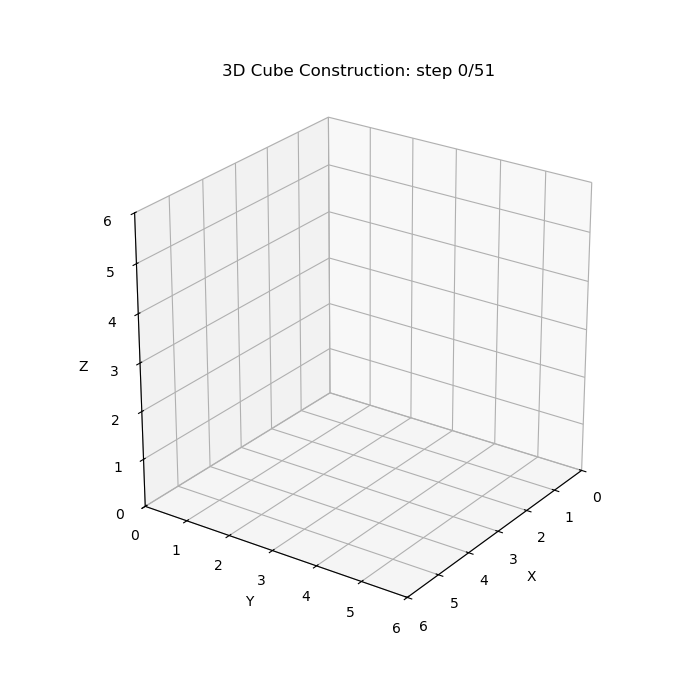

search_7x7x7_mixed_balanced -> outputs\all_case_gifs\search_7x7x7_mixed_balanced_mrv.gif


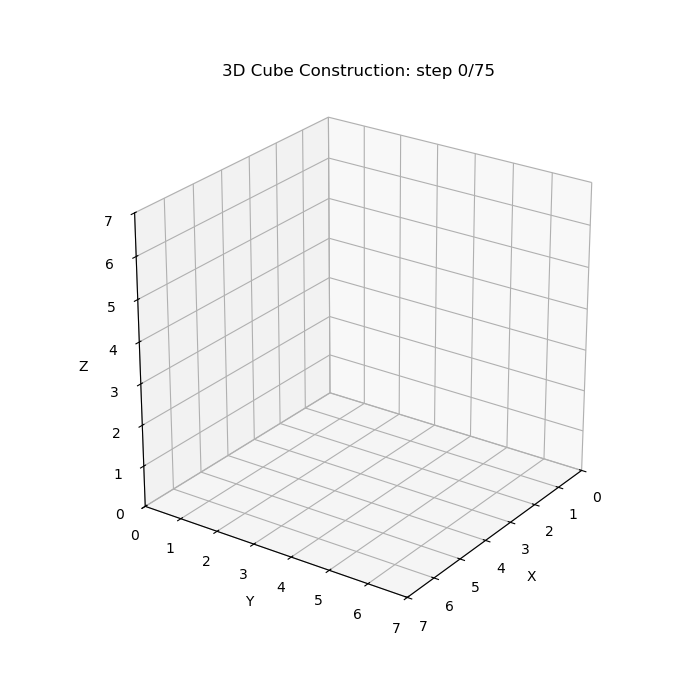

In [7]:
target_cases = [
    'search_6x6x6_mixed_balanced',
    'search_7x7x7_mixed_balanced',
]

row_by_case = {r['case']: r for r in rows}
shown = 0

for case_name in target_cases:
    r = row_by_case.get(case_name)
    if r is None:
        print(f'Missing case in rows: {case_name}')
        continue
    if r['status'] == 'solved' and r['gif_path']:
        print(r['case'], '->', r['gif_path'])
        display(Image(filename=r['gif_path']))
        shown += 1
    else:
        print(f"{case_name} not solved or gif missing. status={r['status']}, gif_path={r['gif_path']}")

if shown == 0:
    print('No target GIFs to preview.')



## Integrating External Instructor Cases

Use this mini tutorial when instructor-provided test cases are not in the same format as this project.

Internal solver input contract (required):
- one case = `List[np.ndarray]`
- each piece = one **3D binary tensor** (`ndim == 3`, occupied voxels are `> 0`)

This section provides adapters for common external formats:
1. `coords`: each piece is a list of `(x, y, z)` coordinates.
2. `dense`: each piece is already a 3D tensor/list.
3. `flat`: each piece is a flattened vector and requires `flat_shape=(X,Y,Z)`.

After conversion, the case runs through the same `build_solver -> solve -> verify` pipeline as all built-in cases.



In [8]:
# External-case adapters (format -> List[np.ndarray])
from __future__ import annotations

from typing import Any, Iterable, List, Tuple
import numpy as np

Coord = Tuple[int, int, int]


def _coords_to_tensor(coords: Iterable[Coord]) -> np.ndarray:
    pts = [tuple(map(int, c)) for c in coords]
    if not pts:
        raise ValueError('Empty coordinate piece is not allowed.')

    arr = np.asarray(pts, dtype=int)
    if arr.ndim != 2 or arr.shape[1] != 3:
        raise ValueError('Coordinate piece must be a list of (x, y, z).')

    # Normalize to start at (0,0,0) so external absolute offsets do not matter.
    mins = arr.min(axis=0)
    arr = arr - mins

    maxs = arr.max(axis=0)
    out = np.zeros((maxs[0] + 1, maxs[1] + 1, maxs[2] + 1), dtype=np.uint8)
    for x, y, z in arr:
        out[x, y, z] = 1
    return out


def _dense_to_tensor(piece: Any) -> np.ndarray:
    arr = np.asarray(piece)
    if arr.ndim != 3:
        raise ValueError(f'Dense piece must be 3D, got shape {arr.shape}.')
    return (arr > 0).astype(np.uint8)


def _flat_to_tensor(piece: Any, flat_shape: Tuple[int, int, int]) -> np.ndarray:
    arr = np.asarray(piece)
    expected = int(np.prod(flat_shape))
    if arr.size != expected:
        raise ValueError(f'Flat piece size {arr.size} != expected {expected} for shape {flat_shape}.')
    arr = arr.reshape(flat_shape)
    return (arr > 0).astype(np.uint8)


def build_external_case(raw_pieces: List[Any], piece_format: str, flat_shape: Tuple[int, int, int] | None = None) -> List[np.ndarray]:
    tensors: List[np.ndarray] = []

    for piece in raw_pieces:
        if piece_format == 'coords':
            tensors.append(_coords_to_tensor(piece))
        elif piece_format == 'dense':
            tensors.append(_dense_to_tensor(piece))
        elif piece_format == 'flat':
            if flat_shape is None:
                raise ValueError('flat_shape is required when piece_format="flat".')
            tensors.append(_flat_to_tensor(piece, flat_shape))
        else:
            raise ValueError(f'Unsupported piece_format: {piece_format}')

    return tensors


def run_external_case(
    case_name: str,
    raw_pieces: List[Any],
    piece_format: str = 'coords',
    flat_shape: Tuple[int, int, int] | None = None,
    backend: str = 'mrv',
    timeout_sec: float = 120,
    interval_ms: int = 400,
    save_gif: bool = True,
):
    pieces = build_external_case(raw_pieces, piece_format=piece_format, flat_shape=flat_shape)
    solver = build_solver(pieces, backend=backend)

    t0 = time.perf_counter()
    placements = solver.solve(max_seconds=timeout_sec)
    dt = time.perf_counter() - t0

    if solver.timed_out:
        status = 'timeout'
    elif solver.infeasible_reason:
        status = 'invalid_input'
    elif placements is None:
        status = 'unsolved'
    else:
        status = 'solved'

    gif_path = ''
    if save_gif and placements is not None:
        out_dir = Path('outputs') / 'external_case_gifs'
        out_dir.mkdir(parents=True, exist_ok=True)
        gif_path = str(out_dir / f'{case_name}_{backend}.gif')
        _ = visualize_solution(solver.n, placements, interval=interval_ms, save_path=gif_path, show=False)

    checks = verify_solution(solver, placements, len(pieces))
    row = {
        'case': case_name,
        'backend': backend,
        'n': getattr(solver, 'n', None),
        'pieces': len(pieces),
        'status': status,
        'runtime_sec': round(dt, 4),
        'timed_out': bool(solver.timed_out),
        'infeasible_reason': solver.infeasible_reason,
        'gif_path': gif_path,
    }
    row.update(checks)

    print(f"[{case_name}] status={status}, runtime={dt:.4f}s, n={row['n']}, pieces={row['pieces']}")
    if gif_path:
        print('saved gif:', gif_path)
        display(Image(filename=gif_path))

    return row, placements



### Example: run one external case in coordinate format

Below example builds a simple 2x2x2 case from coordinate lists (2 pieces, each size 4),
then runs the normal solver workflow.

To use instructor data:
- replace `teacher_raw_case_coords` with instructor piece data,
- set `piece_format` to `coords`, `dense`, or `flat`.



[teacher_demo_2x2x2] status=solved, runtime=0.0002s, n=2, pieces=2
saved gif: outputs\external_case_gifs\teacher_demo_2x2x2_mrv.gif


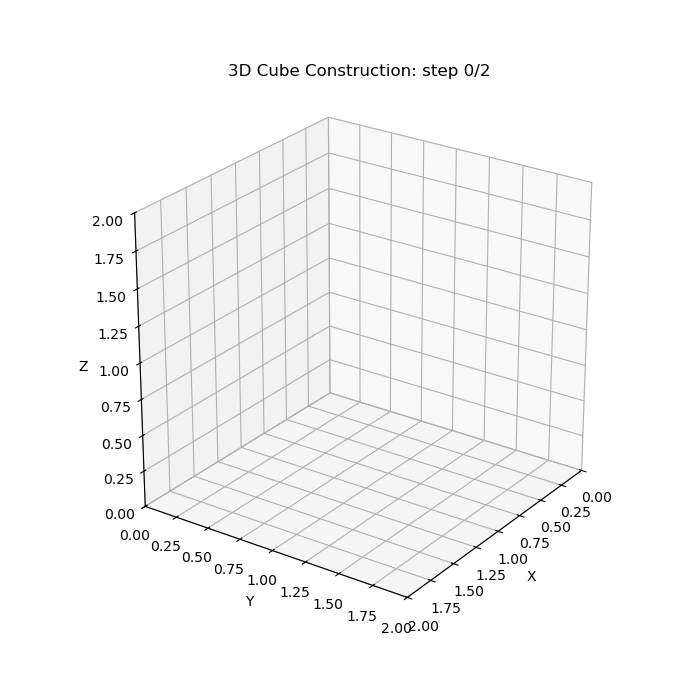

{'case': 'teacher_demo_2x2x2',
 'backend': 'mrv',
 'n': 2,
 'pieces': 2,
 'status': 'solved',
 'runtime_sec': 0.0002,
 'timed_out': False,
 'infeasible_reason': None,
 'gif_path': 'outputs\\external_case_gifs\\teacher_demo_2x2x2_mrv.gif',
 'piece_count_ok': True,
 'piece_used_once_ok': True,
 'no_overlap_ok': True,
 'full_fill_ok': True}

In [9]:
# Example external case (coords format)
teacher_raw_case_coords = [
    [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1)],
    [(1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)],
]

teacher_row, teacher_placements = run_external_case(
    case_name='teacher_demo_2x2x2',
    raw_pieces=teacher_raw_case_coords,
    piece_format='coords',
    backend='mrv',
    timeout_sec=60,
    save_gif=True,
)
teacher_row



### Optional: integrate multiple instructor cases into the existing batch report

If you have multiple instructor cases, use a dictionary and append outputs to `rows`.



In [10]:
# Optional batch integration template
# external_cases = {
#     'instructor_case_a': {'raw_pieces': [...], 'piece_format': 'coords'},
#     'instructor_case_b': {'raw_pieces': [...], 'piece_format': 'dense'},
# }
#
# for name, cfg in external_cases.items():
#     row, _placements = run_external_case(
#         case_name=name,
#         raw_pieces=cfg['raw_pieces'],
#         piece_format=cfg.get('piece_format', 'coords'),
#         flat_shape=cfg.get('flat_shape'),
#         backend=BATCH_BACKEND,
#         timeout_sec=BATCH_TIMEOUT_SEC,
#         interval_ms=BATCH_INTERVAL_MS,
#         save_gif=True,
#     )
#     rows.append(row)
#
# print('external cases appended:', len(external_cases))

